In [3]:
import pandas as pd

In [4]:
ppt=pd.read_csv(r"C:\Users\arjun\Downloads\Property_Price_Train.csv")

In [5]:
ppt.head()

,Id,Building_Class,Zoning_Class,Lot_Extent,Lot_Size,Road_Type,Lane_Type,Property_Shape,Land_Outline,Utility_Type,...,Pool_Area,Pool_Quality,Fence_Quality,Miscellaneous_Feature,Miscellaneous_Value,Month_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price
0,1,60,RLD,65.0,8450,Paved,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RLD,80.0,9600,Paved,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RLD,68.0,11250,Paved,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RLD,60.0,9550,Paved,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RLD,84.0,14260,Paved,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
ppt.shape

(1459, 81)

In [7]:
ppt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         1459 non-null   int64  
 1   Building_Class             1459 non-null   int64  
 2   Zoning_Class               1459 non-null   object 
 3   Lot_Extent                 1200 non-null   float64
 4   Lot_Size                   1459 non-null   int64  
 5   Road_Type                  1459 non-null   object 
 6   Lane_Type                  91 non-null     object 
 7   Property_Shape             1459 non-null   object 
 8   Land_Outline               1459 non-null   object 
 9   Utility_Type               1459 non-null   object 
 10  Lot_Configuration          1459 non-null   object 
 11  Property_Slope             1459 non-null   object 
 12  Neighborhood               1459 non-null   object 
 13  Condition1                 1459 non-null   objec

In [8]:
ppt.isnull().sum()[ppt.isnull().sum()>0]

Lot_Extent                259
Lane_Type                1368
Brick_Veneer_Type         871
Brick_Veneer_Area           8
Basement_Height            37
Basement_Condition         37
Exposure_Level             38
BsmtFinType1               37
BsmtFinType2               38
Electrical_System           1
Fireplace_Quality         689
Garage                     81
Garage_Built_Year          81
Garage_Finish_Year         81
Garage_Quality             81
Garage_Condition           81
Pool_Quality             1452
Fence_Quality            1178
Miscellaneous_Feature    1405
dtype: int64

In [9]:
cols_to_be_dropped =['Lane_Type','Brick_Veneer_Type','Fireplace_Quality','Pool_Quality',
                     'Fence_Quality','Miscellaneous_Feature','Id']

In [10]:
ppt = ppt.drop(cols_to_be_dropped, axis = 1)

In [11]:
ppt.shape

(1459, 74)

In [12]:
ppt.Lot_Extent=ppt.Lot_Extent.fillna(ppt.Lot_Extent.mean())
ppt.Brick_Veneer_Area =ppt.Brick_Veneer_Area.fillna(ppt.Brick_Veneer_Area.mean())
ppt.Basement_Height=ppt.Basement_Height.fillna('TA')
ppt.Basement_Condition=ppt.Basement_Condition.fillna('TA')
ppt.Exposure_Level=ppt.Exposure_Level.fillna('No')
ppt.BsmtFinType1=ppt.BsmtFinType1.fillna('Unf')
ppt.BsmtFinType2=ppt.BsmtFinType2.fillna('Unf')
ppt.Electrical_System =ppt.Electrical_System .fillna('SBrkr')
ppt.Garage=ppt.Garage.fillna('Attchd')
ppt.Garage_Built_Year=ppt.Garage_Built_Year.fillna(ppt.Garage_Built_Year.mean())
ppt.Garage_Finish_Year=ppt.Garage_Finish_Year.fillna('Unf')
ppt.Garage_Quality=ppt.Garage_Quality.fillna('TA')
ppt.Garage_Condition=ppt.Garage_Condition.fillna('TA')

In [13]:
ppt.isnull().sum()[ppt.isnull().sum()>0]

Series([], dtype: int64)

In [14]:
# convert labels to numbers
# any ordinal column(Replace funcn)
# else label encoder

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ppt[ppt.select_dtypes(include='object').columns]=ppt[ppt.select_dtypes(include='object').columns].apply(le.fit_transform)

In [16]:
ppt.select_dtypes(include='object').columns

Index([], dtype='object')

In [17]:
ppt.head()

,Building_Class,Zoning_Class,Lot_Extent,Lot_Size,Road_Type,Property_Shape,Land_Outline,Utility_Type,Lot_Configuration,Property_Slope,...,Enclosed_Lobby_Area,Three_Season_Lobby_Area,Screen_Lobby_Area,Pool_Area,Miscellaneous_Value,Month_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price
0,60,3,65.0,8450,1,3,3,0,4,0,...,20.337934,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,15.039392,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,-46.232198,0,0,0,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,60.921821,0,0,0,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,21.788818,0,0,0,0,12,2008,8,4,250000


In [18]:
# Problem statement : To build a predective model which will predict the sales_price

In [26]:
ppt = df1
from sklearn.model_selection import train_test_split
ppt_train , ppt_test = train_test_split(ppt, test_size = .2)
ppt_train_x = ppt_train.iloc[:,0:-1]
ppt_train_y = ppt_train.iloc[:,-1]
ppt_test_x = ppt_test.iloc[:,0:-1]
ppt_test_y = ppt_test.iloc[:,-1]

In [27]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(ppt_train_x, ppt_train_y)
linreg.score(ppt_train_x, ppt_train_y) 
Rsqu = linreg.score(ppt_train_x, ppt_train_y) 
Rsqu

0.8623744934264471

In [28]:
# Adjusted Rsquare
N = ppt_train_x.shape[0]
k = ppt_train_x.shape[1]
AdjRsquare = 1-(1-Rsqu)*(N-1)/(N-k-1)
AdjRsquare

0.8527327832730216

In [29]:
# Checking the assumptions          # Date= [28-07-26]
# Assumptions checked on the trained data

In [30]:
linreg.fit(ppt_train_x, ppt_train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
pred_train = linreg.predict(ppt_train_x)

In [32]:
error_train=(ppt_train_y - pred_train)

In [33]:
error_train.mean()

np.float64(-2.736177322150986e-10)

In [34]:
import matplotlib.pyplot as plt

In [35]:
import seaborn as sns

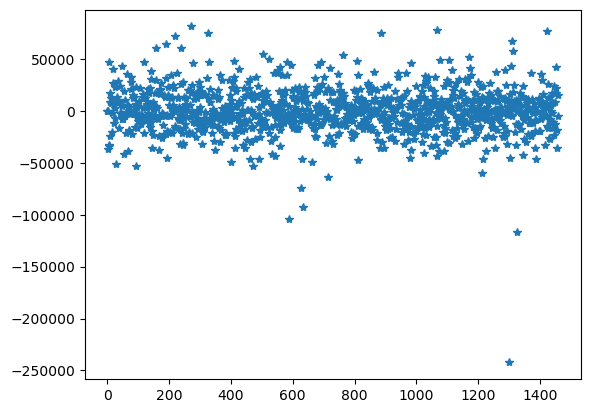

In [36]:
plt.plot(error_train, '*') # sactter plot for error terms

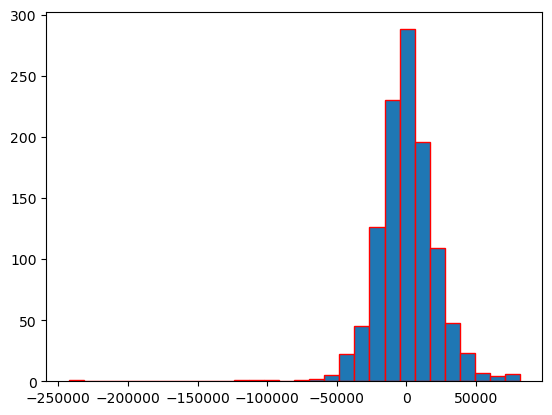

In [37]:
plt.hist(error_train,bins=30, edgecolor = 'red');

In [38]:
actual_pred = pd.DataFrame()    # empty data frame
actual_pred['Actual'] = ppt_train_y
actual_pred['pred'] = pred_train

In [39]:
actual_pred.head(2)

,Actual,pred
1140,139000,124696.720272
674,140000,144251.259640


<Axes: xlabel='Actual', ylabel='pred'>

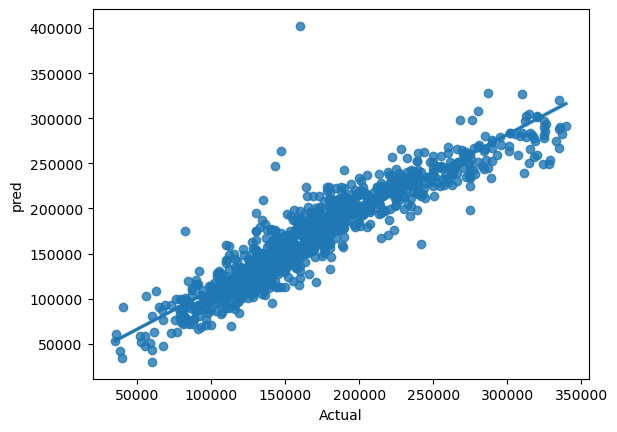

In [40]:
sns.regplot(x = 'Actual' , y= 'pred' , data = actual_pred)

In [41]:
def remove_outliers(df,col,k):  
    mean = df[col].mean()
    global df1
    sd = df[col].std()    
    final_list = [x for x in df[col] if (x > mean - k * sd)]
    final_list = [x for x in final_list if (x < mean + k * sd)]      
    df1 = df.loc[df[col].isin(final_list)] ; print(df1.shape)    
    print("Number of outliers removed == >"   ,  df.shape[0]  - df1.shape[0])

In [42]:
remove_outliers(ppt,'Sale_Price',2)

(1326, 74)
Number of outliers removed == > 70


In [43]:
ppt.shape

(1396, 74)

In [44]:
import numpy as np

In [45]:
from sklearn.metrics import mean_squared_error
mean_squared_error (ppt_train_y , pred_train)

469733092.42487514

In [79]:
mse_train = np.mean(np.square(error_train))
mse_train

np.float64(396262170.26814103)

In [80]:
# 431322203.6681162 before removing outliers
# 396262170.26814103 after removing outliers